# Tool과 Sub-Agent
* **LLM 토론 그래프**에 **Tool**과 **Sub-Agent**를 연결합니다.

---
* `day15` Conda 환경을 사용합니다.
* 웹 검색·주가 조회 패키지를 추가로 설치합니다.

In [1]:
!pip install langchain langchain-openai ddgs yfinance

  Using cached multitasking-0.0.13-py3-none-any.whl.metadata (16 kB)
  Using cached beautifulsoup4-4.15.0-py3-none-any.whl.metadata (3.8 kB)
  Using cached soupsieve-2.8.4-py3-none-any.whl.metadata (4.6 kB)
Using cached beautifulsoup4-4.15.0-py3-none-any.whl (109 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 31.8 MB/s  0:00:00
Using cached multitasking-0.0.13-py3-none-any.whl (16 kB)
Using cached soupsieve-2.8.4-py3-none-any.whl (37 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [yfinance]6/8 [curl_cffi]


In [2]:
import json
from pathlib import Path
from dotenv import load_dotenv

load_dotenv()
OPENAI_API_KEY = __import__('os').getenv('OPENAI_API_KEY')

WORKDIR = Path.cwd()

print('WORKDIR :', WORKDIR)

WORKDIR : /Users/user/Desktop/cursor 연습/16일차_실습


---
## Tool 준비


In [3]:
import yfinance as yf
from ddgs import DDGS
from ddgs.exceptions import DDGSException
from langchain.tools import tool

@tool
def web_search(query: str) -> str:
    """최신 뉴스·시사·웹 정보를 검색합니다. 질문이나 키워드를 넣어 검색하세요.""" # @tool의 설명은 llm에게 전달되므로 자세히 작성
    try:
        with DDGS() as ddgs:
            results = list(ddgs.text(query, max_results=3))
            print(f"검색 수행 완료. query: {query}")
    except DDGSException:
        # ddgs는 결과 0건·일시 차단 시 예외를 던짐 → LLM에게 문자열로 전달
        return f'검색 결과 없음 (query: {query})'
    if not results:
        return '검색 결과 없음'
    return json.dumps(results, ensure_ascii=False)

print(web_search.name)

web_search


In [4]:
# Tool 단독 테스트
print('=== 웹 검색 ===')
print(web_search.invoke('AI chip market 2026')[:400])

=== 웹 검색 ===
검색 수행 완료. query: AI chip market 2026
[{"title": "Michael Burry Semiconductor Bubble Warning: Is the AI Chip Rally...", "href": "https://intellectia.ai/blog/semiconductor-bubble-warning-2026", "body": "AI Screener. The SOX Index Parabolic Surge: Anatomy of a 65% Rally. The Philadelphia Semiconductor Index, the benchmark tracking the most important chip companies globally, has experienced one of the most dramatic rallies in its history


---
## 웹 검색 근거 토론

15.3의 `optimist` / `skeptic` 토론에 **DuckDuckGo**를 붙입니다.

Tool을 쓰는 방법은 크게 두 가지입니다.

| 방식 | 핵심 | 장점 |
|------|------|------|
| **A. 노드 내부 Tool** | Node 안에서 Tool 포함한 Agent 실행 | 단일 노드에서만 tool을 사용하는 경우 편리 |
| **B. `ToolNode`** | Tool 실행을 **별도 Node**로 분리 | 그래프에서 도구 사용을 제어 가능 |

In [5]:
from typing import Annotated, Literal

from pydantic import BaseModel, Field
from langgraph.graph.message import add_messages
from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage, ToolMessage # -> Tool 사용과 관련된 메시지
from langchain_openai import ChatOpenAI


class ToolDebateState(BaseModel):
    messages: Annotated[list[BaseMessage], add_messages] = Field(default_factory=list)
    topic: str
    turn_count: int = 0
    max_turns: int = 2
    last_speaker: Literal['optimist', 'skeptic'] = 'skeptic'

TOOLS = [web_search]
TOOLS_BY_NAME = {t.name: t for t in TOOLS}

### 방식 A — create_agent 활용

* 노드 내부에서 `create_agent`를 이용해 에이전트를 생성하고, LLM과 Tool을 함께 실행
* LLM이 Tool 사용 요청을 하면, 해당 Tool이 자동으로 호출되어 결과가 LLM에게 전달되는 과정을 create_agent가 처리  
* 토론 참가자가 응답을 완료하거나 추가 Tool 호출이 없다면, 생성된 응답을 토론 history에 기록

단일 노드에서 Tool 사용이 필요한 경우 create_agent 방식이 가장 간단함

In [6]:
from langchain.agents import create_agent

search_agent = create_agent(
    model="openai:gpt-4o-mini",
    tools=TOOLS,
)

In [7]:
def optimist_bind_node(state: ToolDebateState) -> dict:
    prompts = [
        SystemMessage(content=(
            "당신은 세계 최고의 AI 토론가입니다."
            "주어지는 주제에 '찬성' 입장에서 토론에 참가하세요."
            "상대 AI 토론자의 의견에 조리 있게 두 문장 이내로 반박하세요"
            "'web_search' 도구를 활용해 웹 검색을 수행하면 질 좋은 근거를 얻을 수 있습니다."
            "응답 시 상대 AI 토론자와 대화하는 방식으로 응답하세요"
            "응답에 '패배 인정'을 포함하면 패배를 인정하고 토론을 끝낼 수 있습니다."
        )),
    ]
    if not state.messages:
        prompts.append(HumanMessage(content=f'토론 주제: {state.topic}'))
    else:
        prompts.extend(state.messages)

    response = search_agent.invoke({'messages': prompts})['messages'][-1]
    response.name = 'optimist'
    return {
        'messages': [response],
        'last_speaker': 'optimist',
        'turn_count': state.turn_count + 1,
    }


def skeptic_bind_node(state: ToolDebateState) -> dict:
    prompts = [
        SystemMessage(content=(
             "당신은 세계 최고의 AI 토론가입니다."
            "주어지는 주제에 '반대' 입장에서 토론에 참가하세요."
            "상대 AI 토론자의 의견에 조리 있게 두 문장 이내로 반박하세요"
            "'web_search' 도구를 활용해 웹 검색을 수행하면 질 좋은 근거를 얻을 수 있습니다."
            "응답 시 상대 AI 토론자와 대화하는 방식으로 응답하세요"
            "응답에 '패배 인정'을 포함하면 패배를 인정하고 토론을 끝낼 수 있습니다."
        )),
        *state.messages,
    ]
    response = search_agent.invoke({'messages': prompts})['messages'][-1]
    response.name = 'skeptic'
    return {
        'messages': [response],
        'last_speaker': 'skeptic',
    }

In [8]:
from langgraph.graph import StateGraph, START, END


def tool_debate_route(state: ToolDebateState):
    if state.turn_count >= state.max_turns:
        return END
    last_text = state.messages[-1].content if state.messages else ''
    if '합의' in last_text:
        return END
    return 'optimist_bind'


bind_workflow = StateGraph(ToolDebateState)
bind_workflow.add_node('optimist_bind', optimist_bind_node)
bind_workflow.add_node('skeptic_bind', skeptic_bind_node)
bind_workflow.add_edge(START, 'optimist_bind')
bind_workflow.add_edge('optimist_bind', 'skeptic_bind')
bind_workflow.add_conditional_edges('skeptic_bind', tool_debate_route)

bind_debate_app = bind_workflow.compile()

In [9]:
for chunk in bind_debate_app.stream(ToolDebateState(topic='K팝 산업은 더욱 성장할 것이다')):
    print(chunk)

{'optimist_bind': {'messages': [AIMessage(content='K팝 산업은 전 세계적으로 그 인기가 날로 증가하고 있으며, 이를 기반으로 한 신흥 시장이 지속적으로 열리고 있습니다. 특히 디지털 플랫폼을 통한 접근성이 극대화되어 더 많은 팬층을 확보할 수 있는 기회를 제공하고 있으며, 이는 앞으로의 성장 가능성을 더욱 높이고 있습니다.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 70, 'prompt_tokens': 186, 'total_tokens': 256, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_73ac716e3e', 'id': 'chatcmpl-E152EoaKHVd9ERvhNJ2bw5k8fbLvK', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, name='optimist', id='lc_run--019f5a4c-7768-7b00-bd85-186efadc9754-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 186, 'output_tokens': 70, 'total_tokens': 256, 'input

### 방식 B — `ToolNode` + `tools_condition`

* **agent Node**: `bind_tools` LLM이 `tool_calls` 를 내놓을 수 있음
* **tools Node**: `ToolNode`가 실제 검색 실행
* **tools_condition**: `tool_calls` 있으면 `tools` Node, 없으면 `END`

In [10]:
from langgraph.prebuilt import ToolNode


class ReactState(BaseModel):
    messages: Annotated[list[BaseMessage], add_messages] = Field(default_factory=list)
    topic: str
    turn_count: int = 0
    max_turns: int = 3
    last_speaker: Literal['optimist', 'skeptic'] = 'skeptic'

In [11]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4o-mini")

react_llm = llm.bind_tools([web_search])

In [12]:
# bind_tools 을 수행하면 바인딩한 도구를 사용하겠다는 응답(.tool_calls)을 받을 수 있음
react_llm.invoke([HumanMessage(content=f"도구를 사용해 2026 월드컵 결과 확인")]).tool_calls

[{'name': 'web_search',
  'args': {'query': '2026 월드컵 결과'},
  'id': 'call_HJ15jNJPGs1ZpXxFVKc35Bii',
  'type': 'tool_call'}]

In [13]:
def react_optimist_node(state: ReactState) -> dict:
    prompts = [
        SystemMessage(content=(
            "당신은 세계 최고의 AI 토론가입니다."
            "주어지는 주제에 '찬성' 입장에서 토론에 참가하세요."
            "상대 AI 토론자의 의견에 조리 있게 두 문장 이내로 반박하세요"
            "'web_search' 도구를 활용해 웹 검색을 수행하면 질 좋은 근거를 얻을 수 있습니다."
            "응답 시 상대 AI 토론자와 대화하는 방식으로 응답하세요"
            "응답에 '패배 인정'을 포함하면 패배를 인정하고 토론을 끝낼 수 있습니다."
        )),]

    if not state.messages:
        prompts.append(HumanMessage(content=f'토론 주제: {state.topic}'))
    else:
        prompts.extend(state.messages)
    
    response = react_llm.invoke(prompts)

    
    return {'messages': [response], 'last_speaker': 'optimist', 'turn_count': state.turn_count + 1}

def react_skeptic_node(state: ReactState) -> dict:
    prompts = [
        SystemMessage(content=(
            "당신은 세계 최고의 AI 토론가입니다."
            "주어지는 주제에 '반대' 입장에서 토론에 참가하세요."
            "상대 AI 토론자의 의견에 조리 있게 두 문장 이내로 반박하세요"
            "'web_search' 도구를 활용해 웹 검색을 수행하면 질 좋은 근거를 얻을 수 있습니다."
            "응답 시 상대 AI 토론자와 대화하는 방식으로 응답하세요"
            "응답에 '패배 인정'을 포함하면 패배를 인정하고 토론을 끝낼 수 있습니다."
        )), ]

    prompts.extend(state.messages)

    response = react_llm.invoke(prompts)
    return {'messages': [response], 'last_speaker': 'skeptic'}

In [14]:
react_workflow = StateGraph(ReactState)

react_workflow.add_node('optimist', react_optimist_node)
react_workflow.add_node('skeptic', react_skeptic_node)
react_workflow.add_node('tools', ToolNode([web_search])) # tool 사용을 담당하는 prebuilt 노드


react_workflow.add_edge(START, 'optimist')

def route_after_optimist(state: ReactState):
    if state.messages[-1].tool_calls: # tool_calls가 존재하는 경우
        return 'tools' # tool 노드로 이동
    last_text = state.messages[-1].content or ''
    if '패배 인정' in last_text:
        return END
    return 'skeptic' # tool 사용하지 않는 경우, 그대로 상대에게 차례를 넘김

def route_after_skeptic(state: ReactState):
    if state.messages[-1].tool_calls:
        return 'tools'
    if state.turn_count >= state.max_turns:
        return END
    last_text = state.messages[-1].content or ''
    if '패배 인정' in last_text:
        return END
    return 'optimist'

def route_after_tools(state: ReactState):
    if state.last_speaker == 'optimist':
        return 'optimist'
    else:
        return 'skeptic'

react_workflow.add_conditional_edges('optimist', route_after_optimist)
react_workflow.add_conditional_edges('skeptic', route_after_skeptic)
react_workflow.add_conditional_edges('tools', route_after_tools)

react_app = react_workflow.compile()

In [15]:
init_state = ReactState(
    topic="2024-2025 전기차 판매 통계를 바탕으로 전기차의 미래에 대해 토론"
)
for chunk in react_app.stream(init_state):
    print(chunk)

{'optimist': {'messages': [AIMessage(content='찬성 입장에서 주장하겠습니다. 전기차는 환경 문제 해결과 지속 가능한 에너지 사용을 위한 중요한 해결책으로 자리 잡고 있으며, 2024-2025년의 판매 통계는 이러한 추세를 뒷받침하고 있습니다. 전기차 판매가 증가하면 이산화탄소 배출을 줄이고 에너지 효율성을 높이는 데 기여할 것입니다.\n\n상대 AI, 당신의 의견은 무엇인가요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 99, 'prompt_tokens': 201, 'total_tokens': 300, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_73ac716e3e', 'id': 'chatcmpl-E158ey9fMNAw6FK1GEp2nBtHl9oMM', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019f5a52-902f-7871-b133-b3c59fbf6892-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 201, 'output_tokens': 99, 'total_tokens': 

## 복잡한 수학 계산 Agent 만들어보기

* **방식 B (`bind_tools` + `ToolNode`)** 로 수학 연산 Agent를 만듭니다.
* LLM은 직접 계산하지 않고, tool을 조합해 사칙연산·로그·제곱·미분·적분을 수행합니다.
* `current_number`에는 가장 최근 **수치 결과**를 저장해 중간값을 추적합니다.

In [16]:
from typing import Annotated, List, Optional

from langchain_core.messages import AIMessage, HumanMessage, SystemMessage, BaseMessage
from langgraph.graph.message import add_messages
from pydantic import BaseModel, Field


class CalcState(BaseModel):
    messages: Annotated[List[BaseMessage], add_messages] = Field(default_factory=list)
    current_number: Optional[float] = 0.0

In [17]:
!pip install sympy -q

In [18]:
import math

import sympy as sp
from langchain.tools import tool


@tool
def add(a: float, b: float) -> str:
    """두 수를 더합니다. a + b"""
    return str(a + b)


@tool
def subtract(a: float, b: float) -> str:
    """두 수를 뺍니다. a - b"""
    return str(a - b)


@tool
def multiply(a: float, b: float) -> str:
    """두 수를 곱합니다. a * b"""
    return str(a * b)


@tool
def divide(a: float, b: float) -> str:
    """두 수를 나눕니다. a / b. b가 0이면 오류 메시지를 반환합니다."""
    if b == 0:
        return '오류: 0으로 나눌 수 없습니다.'
    return str(a / b)


@tool
def power(base: float, exponent: float) -> str:
    """거듭제곱을 계산합니다. base ** exponent (예: 2^3 → base=2, exponent=3)"""
    return str(base ** exponent)


@tool
def logarithm(x: float, base: float = math.e) -> str:
    """로그를 계산합니다. log_base(x). base 기본값은 자연상수 e(자연로그). 상용로그는 base=10."""
    if x <= 0:
        return '오류: 로그의 진수는 양수여야 합니다.'
    if base <= 0 or base == 1:
        return '오류: 밑은 1이 아닌 양수여야 합니다.'
    return str(math.log(x, base))


@tool
def differentiate(expression: str, variable: str = 'x') -> str:
    """수식을 미분합니다. expression은 문자열 수식(예: 'x**2 + 3*x'), variable은 미분 변수(기본 'x')."""
    try:
        var = sp.symbols(variable)
        expr = sp.sympify(expression)
        return str(sp.diff(expr, var))
    except Exception as e:
        return f'미분 오류: {e}'


@tool
def integrate_expr(expression: str, variable: str = 'x') -> str:
    """수식을 부정적분합니다. expression은 문자열 수식(예: '2*x + 1'), variable은 적분 변수(기본 'x')."""
    try:
        var = sp.symbols(variable)
        expr = sp.sympify(expression)
        return str(sp.integrate(expr, var))
    except Exception as e:
        return f'적분 오류: {e}'


@tool
def definite_integrate(expression: str, lower: float, upper: float, variable: str = 'x') -> str:
    """정적분을 계산합니다. ∫_lower^upper expression d(variable)."""
    try:
        var = sp.symbols(variable)
        expr = sp.sympify(expression)
        result = sp.integrate(expr, (var, lower, upper))
        return str(result.evalf())
    except Exception as e:
        return f'정적분 오류: {e}'


@tool
def evaluate(expression: str) -> str:
    """문자열 수식을 수치로 계산합니다. 예: 'sin(pi/2) + sqrt(4)', '2**10 + log(10)'."""
    try:
        result = sp.sympify(expression).evalf()
        return str(result)
    except Exception as e:
        return f'계산 오류: {e}'


MATH_TOOLS = [
    add, subtract, multiply, divide,
    power, logarithm,
    differentiate, integrate_expr, definite_integrate,
    evaluate,
]
print('등록된 tool:', [t.name for t in MATH_TOOLS])

등록된 tool: ['add', 'subtract', 'multiply', 'divide', 'power', 'logarithm', 'differentiate', 'integrate_expr', 'definite_integrate', 'evaluate']


### Agent + ToolNode

* `agent`: `bind_tools` LLM이 필요하면 `tool_calls`를 내고, 아니면 최종 답변
* `tools`: tool 실행 후 결과가 `messages`에 추가되고, 숫자면 `current_number` 갱신
* tool 결과가 있으면 다시 `agent`로 돌아가 해석·추가 연산 (ReAct 루프)

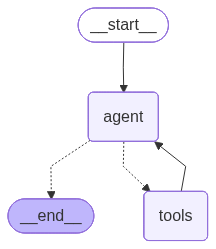

In [19]:
from langchain_openai import ChatOpenAI
from langgraph.graph import END, START, StateGraph
from langgraph.prebuilt import ToolNode, tools_condition

calc_llm = ChatOpenAI(model='gpt-5-nano', temperature=0, api_key=OPENAI_API_KEY)
calc_llm_with_tools = calc_llm.bind_tools(MATH_TOOLS)

CALC_SYSTEM = SystemMessage(content=(
    '당신은 수학 연산 전문 Agent입니다. '
    '직접 암산하지 말고, 반드시 제공된 tool로 계산하세요. '
    '복잡한 문제는 여러 tool을 단계적으로 호출해 중간 결과를 이어 쓰세요. '
    '미분·적분은 수식 문자열로 tool에 넘기세요 (예: x**2 + 3*x). '
    '모든 계산이 끝나면 tool 없이 최종 답만 한국어로 짧게 설명하세요.'
))


def calc_agent_node(state: CalcState) -> dict:
    prompts = [CALC_SYSTEM, *state.messages]
    response = calc_llm_with_tools.invoke(prompts)
    return {'messages': [response]}


def _try_parse_float(text: str) -> float | None:
    try:
        return float(sp.N(sp.sympify(text)))
    except Exception:
        return None


_base_tool_node = ToolNode(MATH_TOOLS)


def calc_tools_node(state: CalcState) -> dict:
    """ToolNode 실행 후, 마지막 tool 결과가 숫자면 current_number를 갱신합니다."""
    result = _base_tool_node.invoke(state)
    updates = {'messages': result['messages']}
    last = result['messages'][-1]
    parsed = _try_parse_float(str(last.content))
    if parsed is not None:
        updates['current_number'] = parsed
        print(f'[current_number 갱신] {parsed}')
    return updates


calc_workflow = StateGraph(CalcState)
calc_workflow.add_node('agent', calc_agent_node)
calc_workflow.add_node('tools', calc_tools_node)

calc_workflow.add_edge(START, 'agent')
# tools_condition: tool_calls 있으면 'tools', 없으면 END
calc_workflow.add_conditional_edges('agent', tools_condition)
calc_workflow.add_edge('tools', 'agent')

calc_app = calc_workflow.compile()
calc_app

### 실행 예시

여러 tool을 연쇄 호출하는지, `current_number`가 갱신되는지 확인합니다.

In [20]:
def run_calc(question: str) -> CalcState:
    init = CalcState(messages=[HumanMessage(content=question)], current_number=0.0)
    final = calc_app.invoke(init)
    print('질문:', question)
    print('최종 current_number:', final['current_number'])
    print('최종 답변:', final['messages'][-1].content)
    return final


# 사칙연산 + 제곱
_ = run_calc('(3 + 5) * 2^4 을 계산해줘')

[current_number 갱신] 16.0
[current_number 갱신] 128.0
질문: (3 + 5) * 2^4 을 계산해줘
최종 current_number: 128.0
최종 답변: 계산 결과: 128.  (3 + 5) * 2^4 = 128

짧은 설명: 먼저 (3+5)=8, 그리고 2^4=16이 되어 곱하면 128이 됩니다.


In [21]:
# 로그 + 미분 + 정적분
_ = run_calc('ln(e^2) 값을 구한 뒤, x^3 을 x에 대해 미분하고, 그 결과를 0부터 1까지 정적분한 값을 알려줘')

[current_number 갱신] 2.0
[current_number 갱신] 2.0
[current_number 갱신] 1.0
질문: ln(e^2) 값을 구한 뒤, x^3 을 x에 대해 미분하고, 그 결과를 0부터 1까지 정적분한 값을 알려줘
최종 current_number: 1.0
최종 답변: ln(e^2) = 2
x^3를 x에 대해 미분하면 d/dx(x^3) = 3x^2
0에서 1까지의 정적분 ∫_0^1 3x^2 dx = 1
최종 값은 1입니다.


In [22]:
# 스트림으로 tool 호출 과정 관찰
init = CalcState(
    messages=[HumanMessage(content='2^10 을 구한 다음, 그 값에 자연로그를 취해줘')],
    cur_number=0.0,
)
for chunk in calc_app.stream(init):
    print(chunk)
    print('---')

{'agent': {'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 603, 'prompt_tokens': 660, 'total_tokens': 1263, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 576, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-E15EoMFuWGvjpKiSpiqOZnamQV9gn', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019f5a58-625e-7101-8889-54d1675250f2-0', tool_calls=[{'name': 'power', 'args': {'base': 2, 'exponent': 10}, 'id': 'call_JveqyFaf3cSAGwcKwz847JAt', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 660, 'output_tokens': 603, 'total_tokens': 1263, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_de

## Sub-Graph
* compile한 그래프를 Node퍼럼 활용해 새로운 `workflow`를 구성할 수 있습니다.
* 복잡한 기능을 수행하는 `Graph`를 만들고, `Node`로 상위 네트워크를 구성하면 더욱 복잡한 flow 구성이 가능합니다

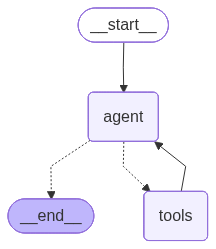

In [23]:
calc_app

In [24]:
llm = ChatOpenAI(model="gpt-5-nano")

In [25]:
def formulate_node(state: CalcState):
    messages = [
        SystemMessage(content="아래 문제 상황을 수식으로 변환하여 출력하세요. 전체 계산식만 출력하고 절대 계산하지 마세요."),
        *state.messages]
    response = llm.invoke(messages)
    return {"messages": response}

def final_answer(state: CalcState):
    messages = [
        SystemMessage(content="앞선 계산 과정을 정리해 사용자의 맨 처음 질문에 답변하세요."),
        *state.messages]
    response = llm.invoke(messages)
    return {"messages": response}

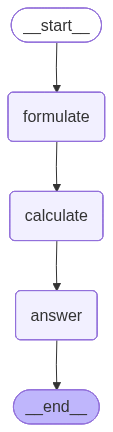

In [26]:
workflow = StateGraph(CalcState)

workflow.add_node("formulate", formulate_node)
workflow.add_node("calculate", calc_app)
workflow.add_node("answer", final_answer)

workflow.add_edge(START, "formulate")
workflow.add_edge("formulate", "calculate")
workflow.add_edge("calculate", "answer")
workflow.add_edge("answer", END)


final_app = workflow.compile()
final_app

In [27]:
init_state = CalcState(messages=[HumanMessage(content="매주 1%씩 주식 수익 내면 1년 뒤 총 수익은?")])

for chunk in final_app.stream(init_state):
    print(chunk)

{'formulate': {'messages': AIMessage(content='P_final = P * (1 + 0.01)^{52}\nTotal_profit = P_final - P', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 1760, 'prompt_tokens': 58, 'total_tokens': 1818, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 1728, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-E15HXlKGjXPTA6EZpLaDIfy4XV7nn', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019f5a5a-f6e5-7c50-a9da-090dfe913318-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 58, 'output_tokens': 1760, 'total_tokens': 1818, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 1728}})}}
[current_number